In [1]:
#predictions for target (0=good, 1=bad)
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

In [2]:
test = pd.read_csv('./application_test.csv')
train = pd.read_csv('./application_train.csv')

In [3]:
print(train.shape)
print(test.shape)

(307511, 122)
(48744, 121)


In [4]:
train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


<AxesSubplot:ylabel='Frequency'>

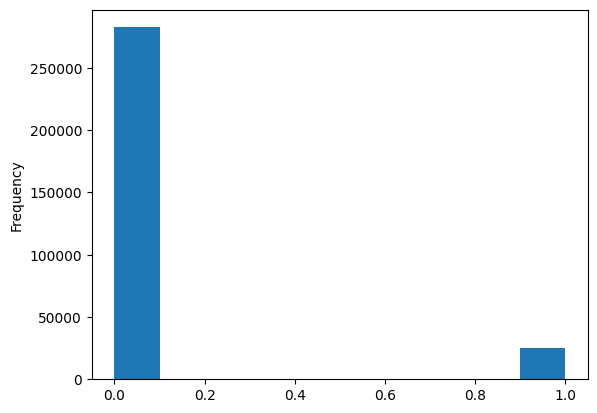

In [5]:
train['TARGET'].astype(int).plot.hist()

In [6]:
train.columns[train.isnull().any()]

Index(['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'OWN_CAR_AGE',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
       'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE',
       'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
       'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE',
       'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
       'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI',
       'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMI

In [7]:
for i in train:
    print(i)

SK_ID_CURR
TARGET
NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
CNT_CHILDREN
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AMT_GOODS_PRICE
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
REGION_POPULATION_RELATIVE
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_REGISTRATION
DAYS_ID_PUBLISH
OWN_CAR_AGE
FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
FLAG_EMAIL
OCCUPATION_TYPE
CNT_FAM_MEMBERS
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
WEEKDAY_APPR_PROCESS_START
HOUR_APPR_PROCESS_START
REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
ORGANIZATION_TYPE
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
APARTMENTS_AVG
BASEMENTAREA_AVG
YEARS_BEGINEXPLUATATION_AVG
YEARS_BUILD_AVG
COMMONAREA_AVG
ELEVATORS_AVG
ENTRANCES_AVG
FLOORSMAX_AVG
FLOORSMIN_AVG
LANDAREA_AVG
LIVINGAPARTMENTS_AVG
LIVINGAREA_AVG
NONLIVINGAPARTMENTS_AVG
NONLIVINGAREA_AVG
APART

In [8]:
train.dtypes.value_counts()

float64    65
int64      41
object     16
dtype: int64

In [9]:
train.select_dtypes('float64').apply(pd.Series.nunique, axis = 0)

AMT_INCOME_TOTAL               2548
AMT_CREDIT                     5603
AMT_ANNUITY                   13672
AMT_GOODS_PRICE                1002
REGION_POPULATION_RELATIVE       81
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY         9
AMT_REQ_CREDIT_BUREAU_WEEK        9
AMT_REQ_CREDIT_BUREAU_MON        24
AMT_REQ_CREDIT_BUREAU_QRT        11
AMT_REQ_CREDIT_BUREAU_YEAR       25
Length: 65, dtype: int64

In [10]:
train.select_dtypes('int64').apply(pd.Series.nunique, axis = 0)

SK_ID_CURR                     307511
TARGET                              2
CNT_CHILDREN                       15
DAYS_BIRTH                      17460
DAYS_EMPLOYED                   12574
DAYS_ID_PUBLISH                  6168
FLAG_MOBIL                          2
FLAG_EMP_PHONE                      2
FLAG_WORK_PHONE                     2
FLAG_CONT_MOBILE                    2
FLAG_PHONE                          2
FLAG_EMAIL                          2
REGION_RATING_CLIENT                3
REGION_RATING_CLIENT_W_CITY         3
HOUR_APPR_PROCESS_START            24
REG_REGION_NOT_LIVE_REGION          2
REG_REGION_NOT_WORK_REGION          2
LIVE_REGION_NOT_WORK_REGION         2
REG_CITY_NOT_LIVE_CITY              2
REG_CITY_NOT_WORK_CITY              2
LIVE_CITY_NOT_WORK_CITY             2
FLAG_DOCUMENT_2                     2
FLAG_DOCUMENT_3                     2
FLAG_DOCUMENT_4                     2
FLAG_DOCUMENT_5                     2
FLAG_DOCUMENT_6                     2
FLAG_DOCUMEN

In [11]:
train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [12]:
# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in train:
    if train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(train[col].unique())) <= 2:
            # Train on the training data
            le.fit(train[col])
            # Transform both training and testing data
            train[col] = le.transform(train[col])
            test[col] = le.transform(test[col])
            # Keep track of how many columns were label encoded
            le_count += 1
            
print(f'{le_count} columns were label encoded.')

3 columns were label encoded.


In [13]:
# one-hot encoding of categorical variables
train = pd.get_dummies(train)
test = pd.get_dummies(test)

print('Training Features shape: ', train.shape)
print('Testing Features shape: ', test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


In [14]:
train['DAYS_BIRTH'].astype(int)
train['DAYS_BIRTH'] = -train['DAYS_BIRTH'] / 365

<AxesSubplot:title={'center':'Age'}, ylabel='Frequency'>

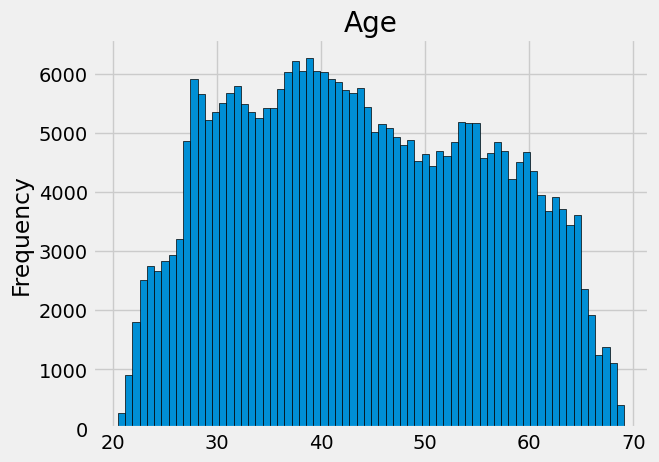

In [86]:
plt.style.use('fivethirtyeight')

train['DAYS_BIRTH'].plot.hist(title = 'Age', edgecolor = 'k', bins=70)

In [16]:
train['DAYS_BIRTH'].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [17]:
train['DAYS_EMPLOYED']
train['DAYS_EMPLOYED'].describe()
365243 / 365

1000.6657534246575

<AxesSubplot:ylabel='Frequency'>

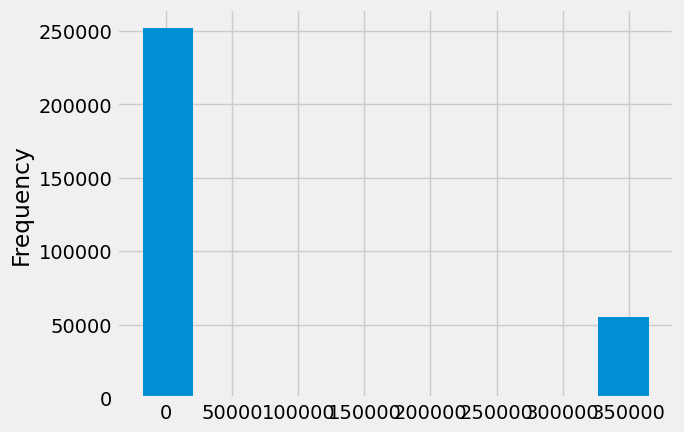

In [18]:
train['DAYS_EMPLOYED'].plot.hist()

In [19]:
anom = train[train['DAYS_EMPLOYED'] == 365243]
print(f'There are {len(anom)} anomalous days of employment')

There are 55374 anomalous days of employment


Text(0.5, 0, 'Days Employment')

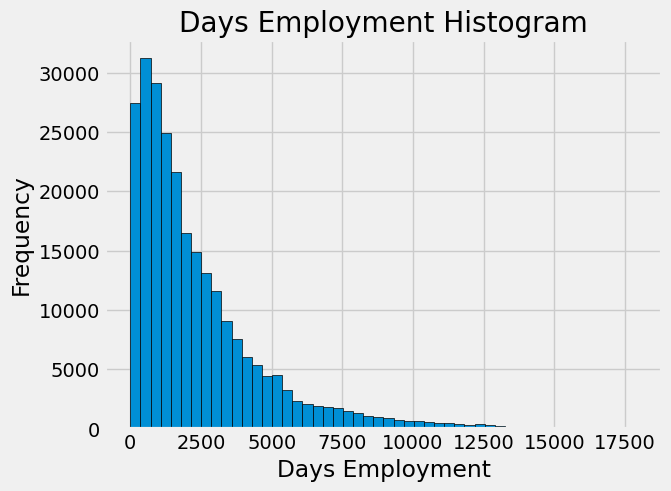

In [20]:
# Create an anomalous flag column
train['DAYS_EMPLOYED_ANOM'] = train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

train['DAYS_EMPLOYED'] = abs(train['DAYS_EMPLOYED'])

train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram', edgecolor='k', bins=50)
plt.xlabel('Days Employment')

Text(0.5, 0, 'Years Employment')

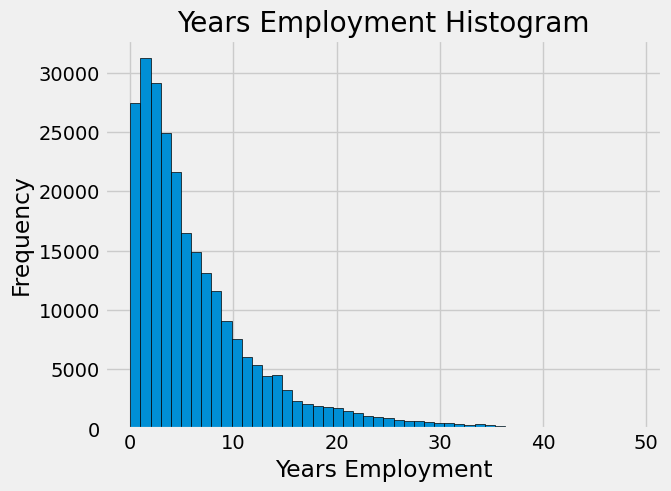

In [21]:
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'] / 365
train['DAYS_EMPLOYED'].plot.hist(title = 'Years Employment Histogram', edgecolor='k', bins=50)
plt.xlabel('Years Employment')

In [22]:
correlations = train.corr()['TARGET'].sort_values() * 100

In [23]:
correlations = correlations.sort_values(ascending=False)

In [24]:
correlations.head(25)

TARGET                                               100.000000
REGION_RATING_CLIENT_W_CITY                            6.089267
REGION_RATING_CLIENT                                   5.889901
NAME_INCOME_TYPE_Working                               5.748118
DAYS_LAST_PHONE_CHANGE                                 5.521848
CODE_GENDER_M                                          5.471268
DAYS_ID_PUBLISH                                        5.145717
REG_CITY_NOT_WORK_CITY                                 5.099446
NAME_EDUCATION_TYPE_Secondary / secondary special      4.982373
FLAG_EMP_PHONE                                         4.598222
REG_CITY_NOT_LIVE_CITY                                 4.439537
FLAG_DOCUMENT_3                                        4.434635
OCCUPATION_TYPE_Laborers                               4.301895
DAYS_REGISTRATION                                      4.197486
OWN_CAR_AGE                                            3.761156
LIVE_CITY_NOT_WORK_CITY                 

In [25]:
correlations.tail(25)

FLOORSMIN_MODE                          -3.269783
LIVINGAREA_MEDI                         -3.273928
LIVINGAREA_AVG                          -3.299712
WALLSMATERIAL_MODE_Panel                -3.311905
FLOORSMIN_MEDI                          -3.339429
FLOORSMIN_AVG                           -3.361350
ELEVATORS_MEDI                          -3.386288
ELEVATORS_AVG                           -3.419879
REGION_POPULATION_RELATIVE              -3.722715
AMT_GOODS_PRICE                         -3.964528
HOUSETYPE_MODE_block of flats           -4.059395
EMERGENCYSTATE_MODE_No                  -4.220136
FLOORSMAX_MODE                          -4.322626
FLOORSMAX_MEDI                          -4.376792
FLOORSMAX_AVG                           -4.400337
DAYS_EMPLOYED_ANOM                      -4.598708
ORGANIZATION_TYPE_XNA                   -4.598708
NAME_INCOME_TYPE_Pensioner              -4.620942
CODE_GENDER_F                           -5.470405
NAME_EDUCATION_TYPE_Higher education    -5.659264


<AxesSubplot:title={'center':'REGION_RATING_CLIENT_W_CITY'}, ylabel='Frequency'>

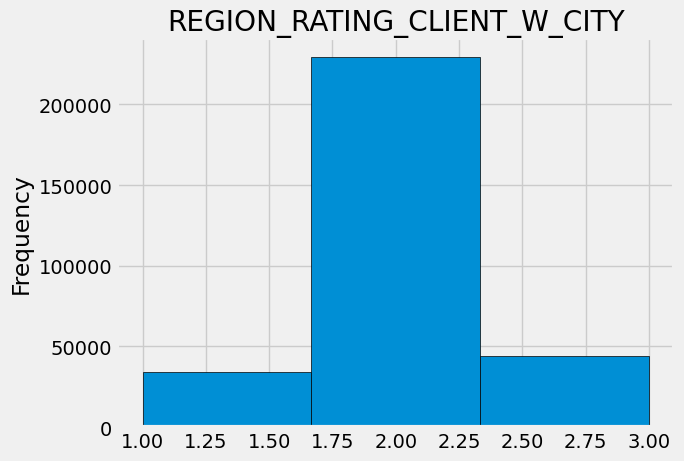

In [26]:
train['REGION_RATING_CLIENT_W_CITY'].astype(int)
train['REGION_RATING_CLIENT_W_CITY'].plot.hist(title='REGION_RATING_CLIENT_W_CITY', bins=3, edgecolor='k')

<AxesSubplot:title={'center':'REGION_RATING_CLIENT'}, ylabel='Frequency'>

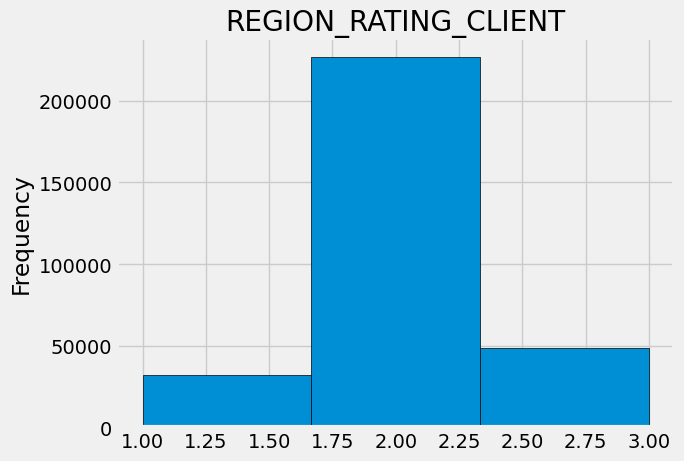

In [27]:
train['REGION_RATING_CLIENT'].plot.hist(title='REGION_RATING_CLIENT', bins=3, edgecolor='k')

In [28]:
train['NAME_INCOME_TYPE_Working'].nunique()

2

<AxesSubplot:ylabel='Frequency'>

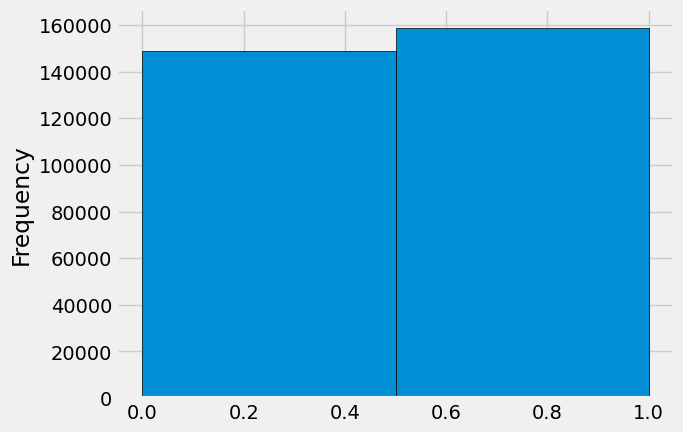

In [29]:
train['NAME_INCOME_TYPE_Working'].plot.hist(bins=2, edgecolor='k')

In [30]:
train.columns[train.apply(pd.Series.nunique) == 2]

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL',
       ...
       'WALLSMATERIAL_MODE_Block', 'WALLSMATERIAL_MODE_Mixed',
       'WALLSMATERIAL_MODE_Monolithic', 'WALLSMATERIAL_MODE_Others',
       'WALLSMATERIAL_MODE_Panel', 'WALLSMATERIAL_MODE_Stone, brick',
       'WALLSMATERIAL_MODE_Wooden', 'EMERGENCYSTATE_MODE_No',
       'EMERGENCYSTATE_MODE_Yes', 'DAYS_EMPLOYED_ANOM'],
      dtype='object', length=171)

In [31]:
correlations.head(25)

TARGET                                               100.000000
REGION_RATING_CLIENT_W_CITY                            6.089267
REGION_RATING_CLIENT                                   5.889901
NAME_INCOME_TYPE_Working                               5.748118
DAYS_LAST_PHONE_CHANGE                                 5.521848
CODE_GENDER_M                                          5.471268
DAYS_ID_PUBLISH                                        5.145717
REG_CITY_NOT_WORK_CITY                                 5.099446
NAME_EDUCATION_TYPE_Secondary / secondary special      4.982373
FLAG_EMP_PHONE                                         4.598222
REG_CITY_NOT_LIVE_CITY                                 4.439537
FLAG_DOCUMENT_3                                        4.434635
OCCUPATION_TYPE_Laborers                               4.301895
DAYS_REGISTRATION                                      4.197486
OWN_CAR_AGE                                            3.761156
LIVE_CITY_NOT_WORK_CITY                 

In [32]:
correlations['DAYS_BIRTH']

-7.823930830982544

In [33]:
train.nunique().shape

(244,)

In [34]:
train.nunique().sort_values(ascending=False).head(25)

SK_ID_CURR                307511
EXT_SOURCE_2              119831
EXT_SOURCE_1              114584
DAYS_BIRTH                 17460
DAYS_REGISTRATION          15688
AMT_ANNUITY                13672
DAYS_EMPLOYED              12573
DAYS_ID_PUBLISH             6168
AMT_CREDIT                  5603
LIVINGAREA_MODE             5301
LIVINGAREA_MEDI             5281
LIVINGAREA_AVG              5199
TOTALAREA_MODE              5116
BASEMENTAREA_MODE           3841
BASEMENTAREA_AVG            3780
DAYS_LAST_PHONE_CHANGE      3773
BASEMENTAREA_MEDI           3772
LANDAREA_MODE               3563
LANDAREA_MEDI               3560
LANDAREA_AVG                3527
NONLIVINGAREA_MODE          3327
NONLIVINGAREA_MEDI          3323
NONLIVINGAREA_AVG           3290
COMMONAREA_MEDI             3202
COMMONAREA_AVG              3181
dtype: int64

In [35]:
train['DAYS_BIRTH'].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [36]:
# Age information into a separate dataframe
age_data = train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH']
age_data = age_data.drop(['DAYS_BIRTH'], axis=1)

In [37]:
age_data.head()

,TARGET,YEARS_BIRTH
0,1,25.920548
1,0,45.931507
2,0,52.180822
3,0,52.068493
4,0,54.608219


In [38]:
# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data

,TARGET,YEARS_BIRTH,YEARS_BINNED
0,1,25.920548,"(25.0, 30.0]"
1,0,45.931507,"(45.0, 50.0]"
2,0,52.180822,"(50.0, 55.0]"
3,0,52.068493,"(50.0, 55.0]"
4,0,54.608219,"(50.0, 55.0]"
...,...,...,...
307506,0,25.553425,"(25.0, 30.0]"
307507,0,56.917808,"(55.0, 60.0]"
307508,0,41.002740,"(40.0, 45.0]"
307509,1,32.769863,"(30.0, 35.0]"


In [39]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,YEARS_BIRTH
YEARS_BINNED,,
"(20.0, 25.0]",0.123036,23.377522
"(25.0, 30.0]",0.111436,27.822518
"(30.0, 35.0]",0.102814,32.479037
"(35.0, 40.0]",0.089414,37.555913
"(40.0, 45.0]",0.078491,42.459346
"(45.0, 50.0]",0.074171,47.462741
"(50.0, 55.0]",0.066968,52.593136
"(55.0, 60.0]",0.055314,57.491131
"(60.0, 65.0]",0.052737,62.412459


In [40]:
age_groups.shape

(10, 2)

Text(0.5, 1.0, 'Failure to Repay by Age Group')

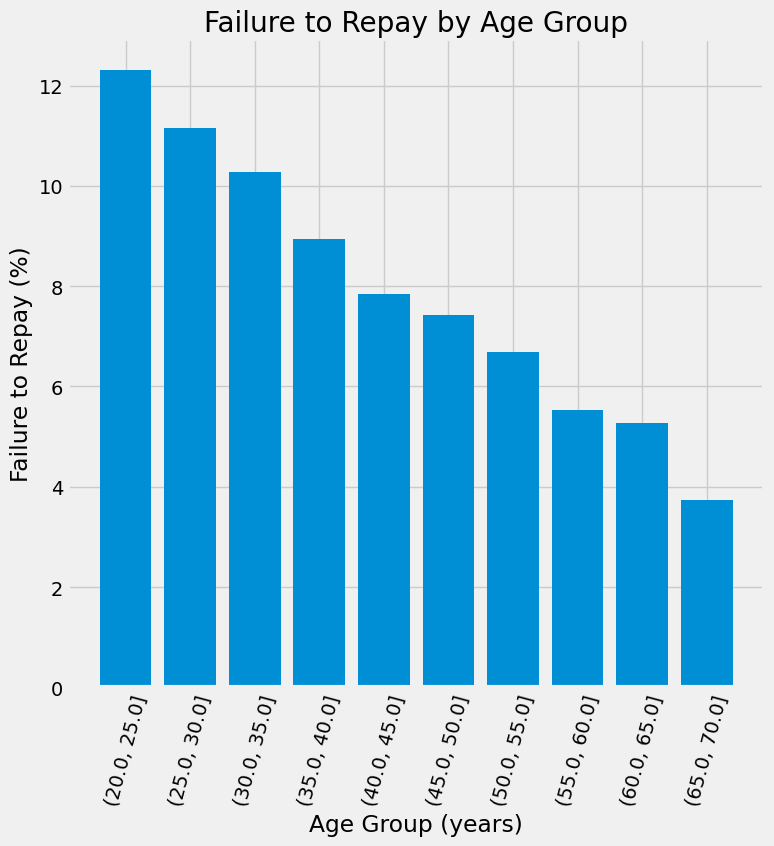

In [41]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group')

In [42]:
# Age information into a separate dataframe
regis = abs(train[['TARGET', 'DAYS_REGISTRATION']])
regis['YEARS_REGISTRATION'] = regis['DAYS_REGISTRATION'] / 365
regis

,TARGET,DAYS_REGISTRATION,YEARS_REGISTRATION
0,1,3648.0,9.994521
1,0,1186.0,3.249315
2,0,4260.0,11.671233
3,0,9833.0,26.939726
4,0,4311.0,11.810959
...,...,...,...
307506,0,8456.0,23.167123
307507,0,4388.0,12.021918
307508,0,6737.0,18.457534
307509,1,2562.0,7.019178


In [43]:
regis['YEARS_REGISTRATION'].describe()

count    307511.000000
mean         13.660604
std           9.651743
min           0.000000
25%           5.506849
50%          12.339726
75%          20.491781
max          67.594521
Name: YEARS_REGISTRATION, dtype: float64

In [44]:
# Bin the age data
regis['YEARS_BINNED'] = pd.cut(regis['YEARS_REGISTRATION'], bins = np.linspace(0, 70, num = 11))
regis

,TARGET,DAYS_REGISTRATION,YEARS_REGISTRATION,YEARS_BINNED
0,1,3648.0,9.994521,"(7.0, 14.0]"
1,0,1186.0,3.249315,"(0.0, 7.0]"
2,0,4260.0,11.671233,"(7.0, 14.0]"
3,0,9833.0,26.939726,"(21.0, 28.0]"
4,0,4311.0,11.810959,"(7.0, 14.0]"
...,...,...,...,...
307506,0,8456.0,23.167123,"(21.0, 28.0]"
307507,0,4388.0,12.021918,"(7.0, 14.0]"
307508,0,6737.0,18.457534,"(14.0, 21.0]"
307509,1,2562.0,7.019178,"(7.0, 14.0]"


In [45]:
regis_new = regis.drop(['DAYS_REGISTRATION'], axis=1)
regis_new = regis_new.groupby(['YEARS_BINNED']).mean()
regis_new

,TARGET,YEARS_REGISTRATION
YEARS_BINNED,,
"(0.0, 7.0]",0.090784,3.143534
"(7.0, 14.0]",0.087089,10.593718
"(14.0, 21.0]",0.078167,17.341956
"(21.0, 28.0]",0.066923,24.268306
"(28.0, 35.0]",0.058338,30.974605
"(35.0, 42.0]",0.050393,37.497433
"(42.0, 49.0]",0.039851,44.197004
"(49.0, 56.0]",0.051282,51.193888
"(56.0, 63.0]",0.040000,58.303452


Text(0.5, 1.0, 'Failure to Repay by years registration Group')

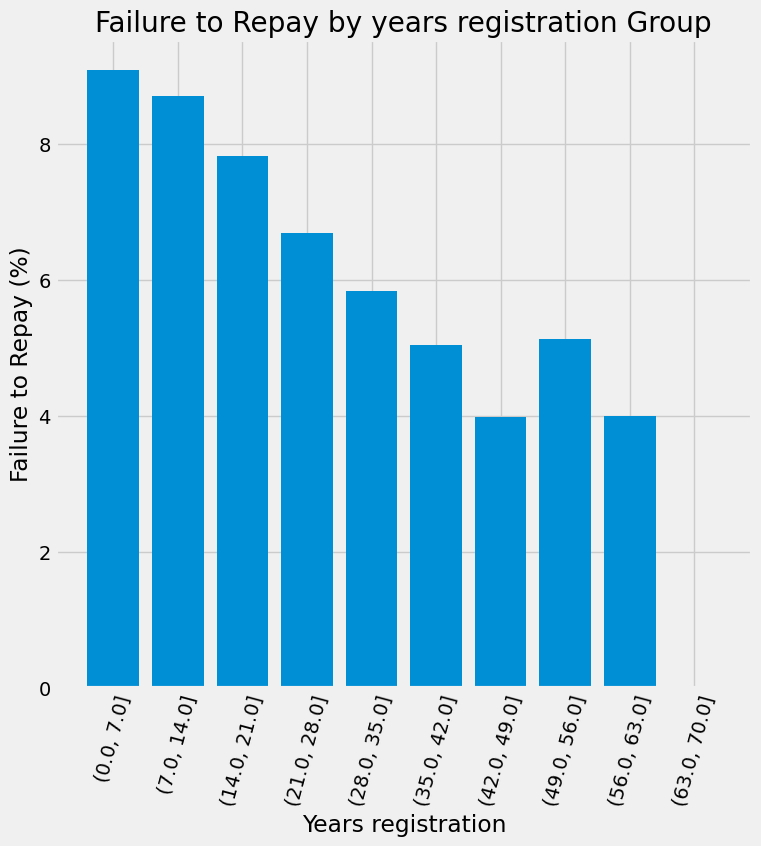

In [46]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(regis_new.index.astype(str), 100 * regis_new['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Years registration'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by years registration Group')

In [47]:
train['AMT_INCOME_TOTAL'].nunique()

2548

In [48]:
train['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

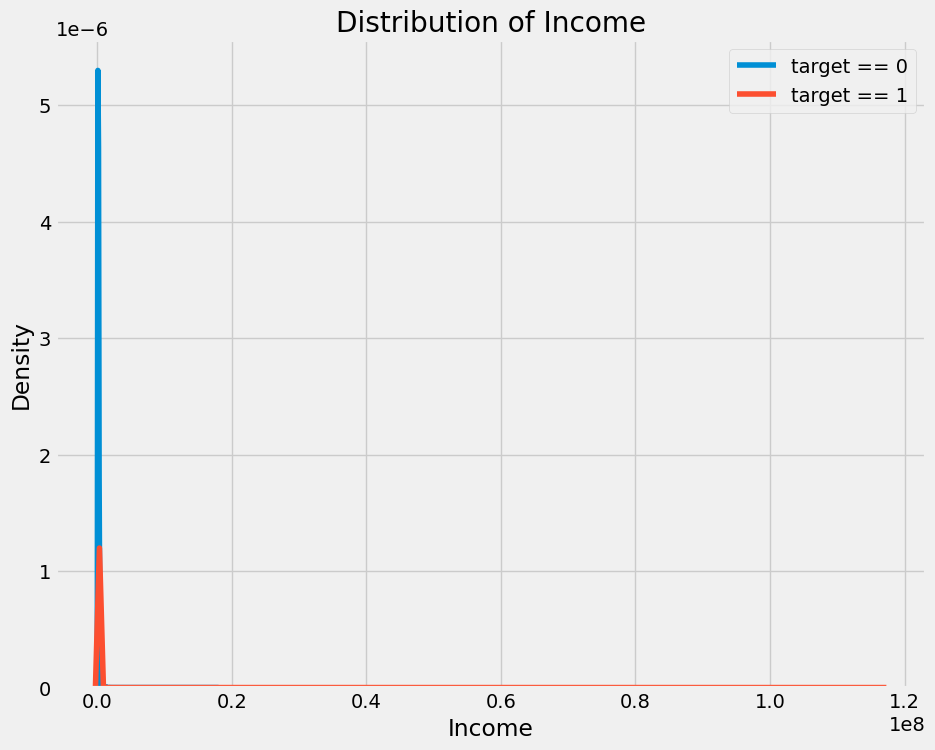

In [49]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 0, 'AMT_INCOME_TOTAL'], label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 1, 'AMT_INCOME_TOTAL'], label = 'target == 1')

# Labeling of plot
plt.xlabel('Income'); plt.ylabel('Density'); plt.title('Distribution of Income');

plt.legend()

<AxesSubplot:ylabel='Frequency'>

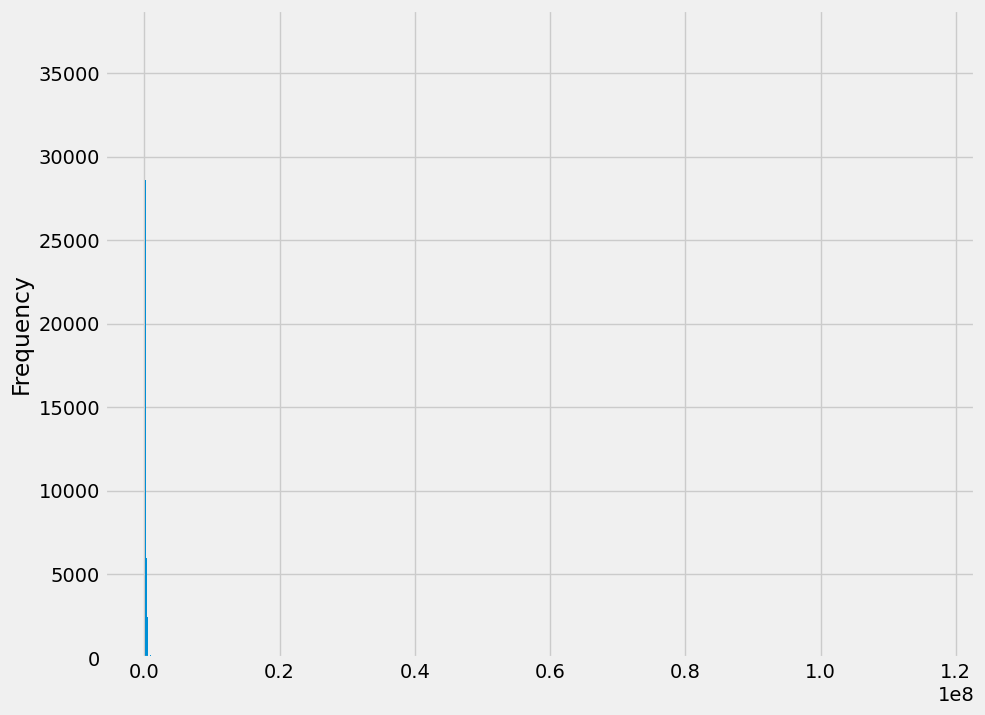

In [50]:
plt.figure(figsize = (10, 8))
train['AMT_INCOME_TOTAL'].plot.hist(bins=10000)

In [51]:
correlations['AMT_INCOME_TOTAL']
#which makes sense

-0.3981865601205793

In [52]:
train.nunique().sort_values(ascending=False).head(25)

SK_ID_CURR                307511
EXT_SOURCE_2              119831
EXT_SOURCE_1              114584
DAYS_BIRTH                 17460
DAYS_REGISTRATION          15688
AMT_ANNUITY                13672
DAYS_EMPLOYED              12573
DAYS_ID_PUBLISH             6168
AMT_CREDIT                  5603
LIVINGAREA_MODE             5301
LIVINGAREA_MEDI             5281
LIVINGAREA_AVG              5199
TOTALAREA_MODE              5116
BASEMENTAREA_MODE           3841
BASEMENTAREA_AVG            3780
DAYS_LAST_PHONE_CHANGE      3773
BASEMENTAREA_MEDI           3772
LANDAREA_MODE               3563
LANDAREA_MEDI               3560
LANDAREA_AVG                3527
NONLIVINGAREA_MODE          3327
NONLIVINGAREA_MEDI          3323
NONLIVINGAREA_AVG           3290
COMMONAREA_MEDI             3202
COMMONAREA_AVG              3181
dtype: int64

In [53]:
train['DAYS_EMPLOYED'].describe()

count    252137.000000
mean          6.531971
std           6.406466
min          -0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: DAYS_EMPLOYED, dtype: float64

<AxesSubplot:ylabel='Frequency'>

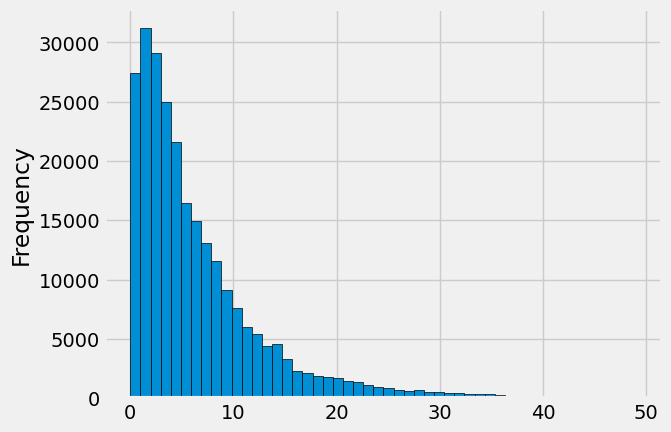

In [54]:
train['DAYS_EMPLOYED'].plot.hist(bins=50, edgecolor='k')

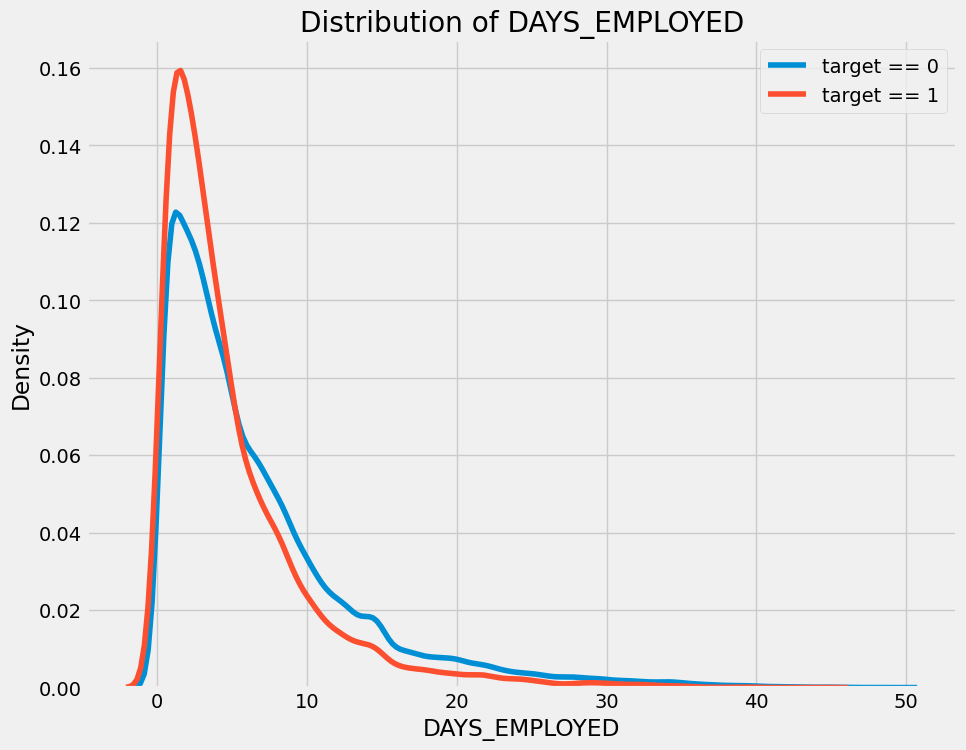

In [55]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 0, 'DAYS_EMPLOYED'], label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 1, 'DAYS_EMPLOYED'], label = 'target == 1')

# Labeling of plot
plt.xlabel('DAYS_EMPLOYED'); plt.ylabel('Density'); plt.title('Distribution of DAYS_EMPLOYED')

plt.legend()

In [56]:
employed = train[['TARGET', 'DAYS_EMPLOYED']]
employed

,TARGET,DAYS_EMPLOYED
0,1,1.745205
1,0,3.254795
2,0,0.616438
3,0,8.326027
4,0,8.323288
...,...,...
307506,0,0.646575
307507,0,NaN
307508,0,21.701370
307509,1,13.112329


In [57]:
employed['DAYS_EMPLOYED'].nunique()

12573

In [58]:
# Bin the age data
employed['EMPLOYED_BIN'] = pd.cut(employed['DAYS_EMPLOYED'], bins = np.linspace(0, 50, num = 11))
employed

,TARGET,DAYS_EMPLOYED,EMPLOYED_BIN
0,1,1.745205,"(0.0, 5.0]"
1,0,3.254795,"(0.0, 5.0]"
2,0,0.616438,"(0.0, 5.0]"
3,0,8.326027,"(5.0, 10.0]"
4,0,8.323288,"(5.0, 10.0]"
...,...,...,...
307506,0,0.646575,"(0.0, 5.0]"
307507,0,NaN,NaN
307508,0,21.701370,"(20.0, 25.0]"
307509,1,13.112329,"(10.0, 15.0]"


In [59]:
employed['DAYS_EMPLOYED'].isna().sum()

55374

In [60]:
employed = employed[employed['DAYS_EMPLOYED'].notna()]
employed

,TARGET,DAYS_EMPLOYED,EMPLOYED_BIN
0,1,1.745205,"(0.0, 5.0]"
1,0,3.254795,"(0.0, 5.0]"
2,0,0.616438,"(0.0, 5.0]"
3,0,8.326027,"(5.0, 10.0]"
4,0,8.323288,"(5.0, 10.0]"
...,...,...,...
307504,0,19.884932,"(15.0, 20.0]"
307506,0,0.646575,"(0.0, 5.0]"
307508,0,21.701370,"(20.0, 25.0]"
307509,1,13.112329,"(10.0, 15.0]"


In [61]:
employed = employed.groupby(['EMPLOYED_BIN']).mean()
employed

,TARGET,DAYS_EMPLOYED
EMPLOYED_BIN,,
"(0.0, 5.0]",0.105708,2.368057
"(5.0, 10.0]",0.073714,7.206095
"(10.0, 15.0]",0.057752,12.238081
"(15.0, 20.0]",0.048484,17.279070
"(20.0, 25.0]",0.047573,22.172262
"(25.0, 30.0]",0.039903,27.291609
"(30.0, 35.0]",0.041258,32.306168
"(35.0, 40.0]",0.019231,37.034615
"(40.0, 45.0]",0.004762,41.987567


Text(0.5, 1.0, 'Failure to Repay by DAYS_EMPLOYED')

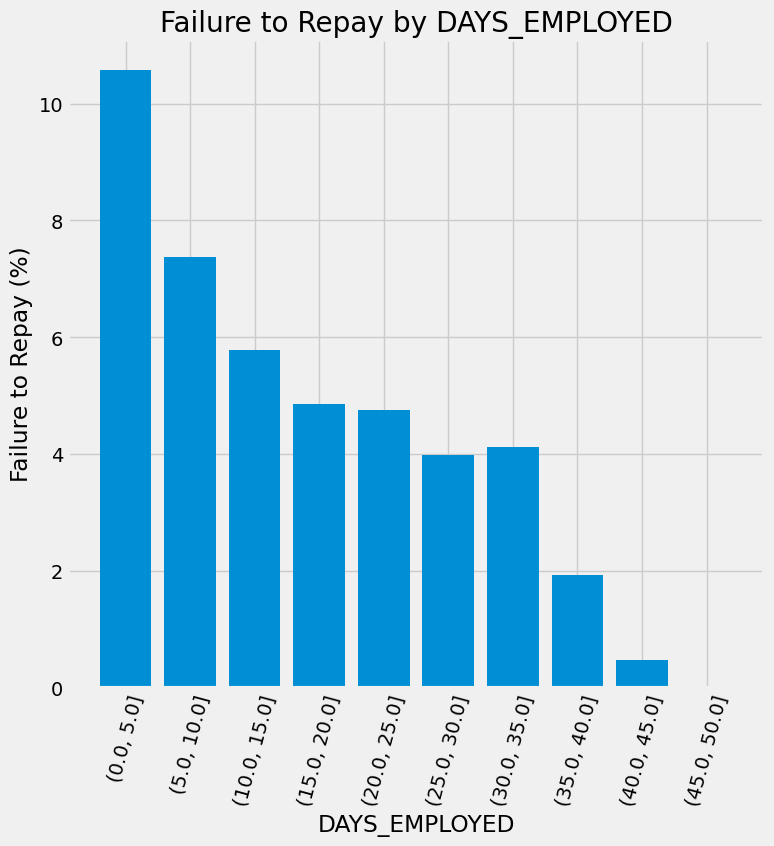

In [62]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(employed.index.astype(str), 100 * employed['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('DAYS_EMPLOYED'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by DAYS_EMPLOYED')

In [63]:
correlations['DAYS_EMPLOYED']
#makes sense

-7.495845742543761

In [64]:
a = train.nunique().sort_values(ascending=False)

In [65]:
b = correlations

In [66]:
a.head()

SK_ID_CURR           307511
EXT_SOURCE_2         119831
EXT_SOURCE_1         114584
DAYS_BIRTH            17460
DAYS_REGISTRATION     15688
dtype: int64

In [67]:
b.head()

TARGET                         100.000000
REGION_RATING_CLIENT_W_CITY      6.089267
REGION_RATING_CLIENT             5.889901
NAME_INCOME_TYPE_Working         5.748118
DAYS_LAST_PHONE_CHANGE           5.521848
Name: TARGET, dtype: float64

In [68]:
b.shape

(244,)

In [69]:
a.head(10)

SK_ID_CURR           307511
EXT_SOURCE_2         119831
EXT_SOURCE_1         114584
DAYS_BIRTH            17460
DAYS_REGISTRATION     15688
AMT_ANNUITY           13672
DAYS_EMPLOYED         12573
DAYS_ID_PUBLISH        6168
AMT_CREDIT             5603
LIVINGAREA_MODE        5301
dtype: int64

In [70]:
print(a.shape)
print(b.shape)

(244,)
(244,)


In [71]:
unique_cor = pd.concat([a, b], axis=1)

unique_cor.set_axis(['UNIQUE', 'CORRELATION'], axis='columns', inplace=True)

unique_cor.index.name = 'COLUMN_NAME'

In [72]:
unique_cor = unique_cor.sort_values(['CORRELATION'], ascending=False)
unique_cor = unique_cor[unique_cor['UNIQUE'] > 2]
unique_cor

,UNIQUE,CORRELATION
COLUMN_NAME,,
REGION_RATING_CLIENT_W_CITY,3,6.089267
REGION_RATING_CLIENT,3,5.889901
DAYS_LAST_PHONE_CHANGE,3773,5.521848
DAYS_ID_PUBLISH,6168,5.145717
DAYS_REGISTRATION,15688,4.197486
...,...,...
DAYS_EMPLOYED,12573,-7.495846
DAYS_BIRTH,17460,-7.823931
EXT_SOURCE_1,114584,-15.531713


In [73]:
train['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

<AxesSubplot:ylabel='Frequency'>

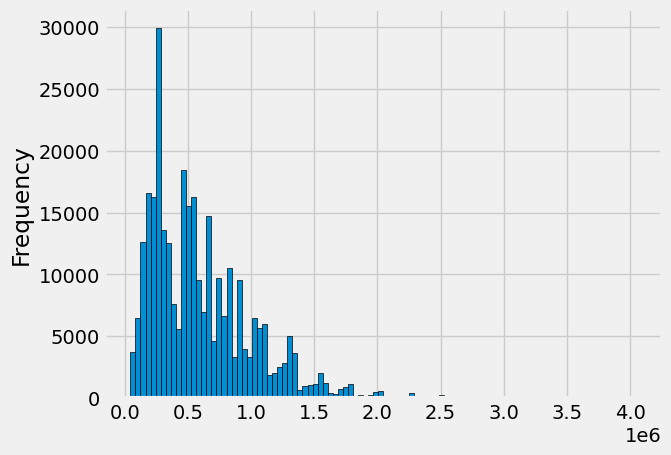

In [74]:
train['AMT_CREDIT'].plot.hist(edgecolor='k', bins=100)

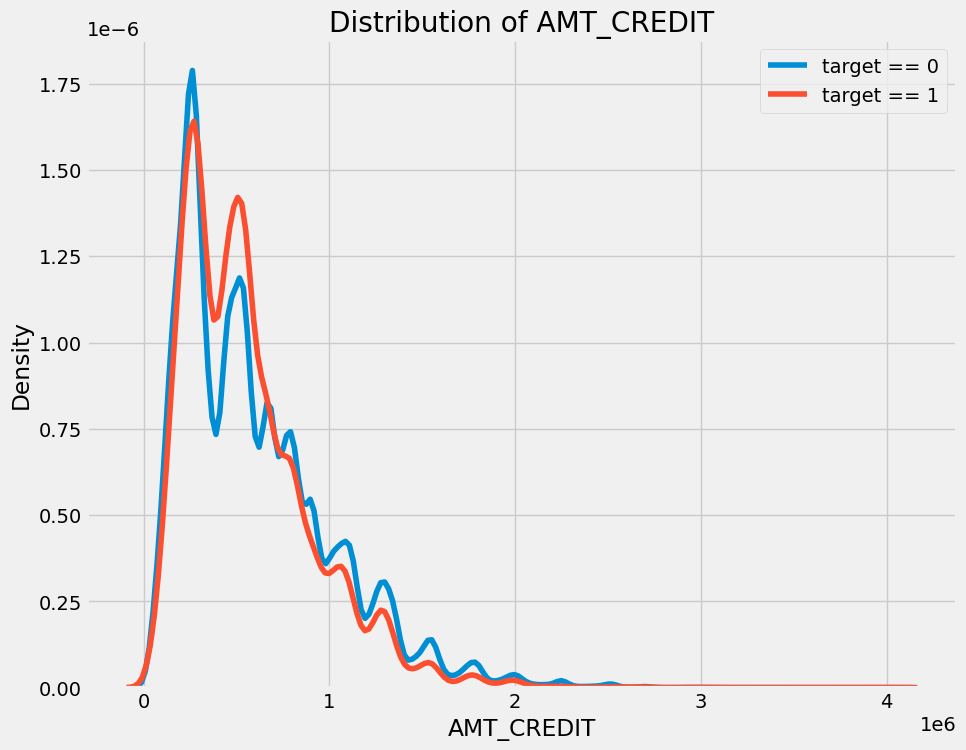

In [75]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 0, 'AMT_CREDIT'], label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 1, 'AMT_CREDIT'], label = 'target == 1')

# Labeling of plot
plt.xlabel('AMT_CREDIT'); plt.ylabel('Density'); plt.title('Distribution of AMT_CREDIT')

plt.legend()

In [76]:
train['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

<AxesSubplot:ylabel='Frequency'>

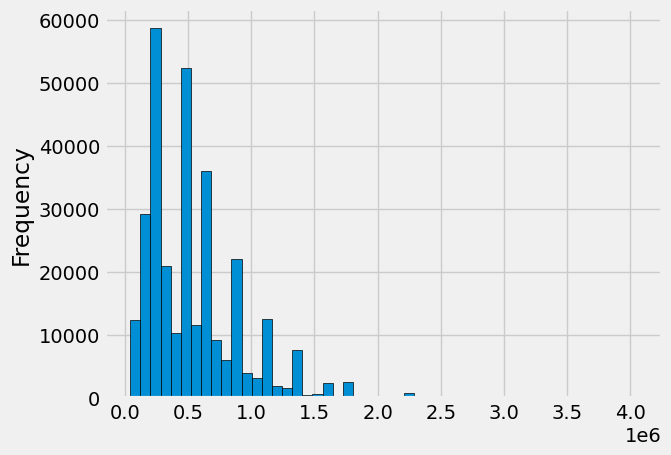

In [77]:
train['AMT_GOODS_PRICE'].plot.hist(edgecolor='k', bins=50)

In [78]:
train['DAYS_LAST_PHONE_CHANGE'] = abs(train['DAYS_LAST_PHONE_CHANGE'])

In [79]:
train['DAYS_LAST_PHONE_CHANGE'].describe()

count    307510.000000
mean        962.858788
std         826.808487
min           0.000000
25%         274.000000
50%         757.000000
75%        1570.000000
max        4292.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64

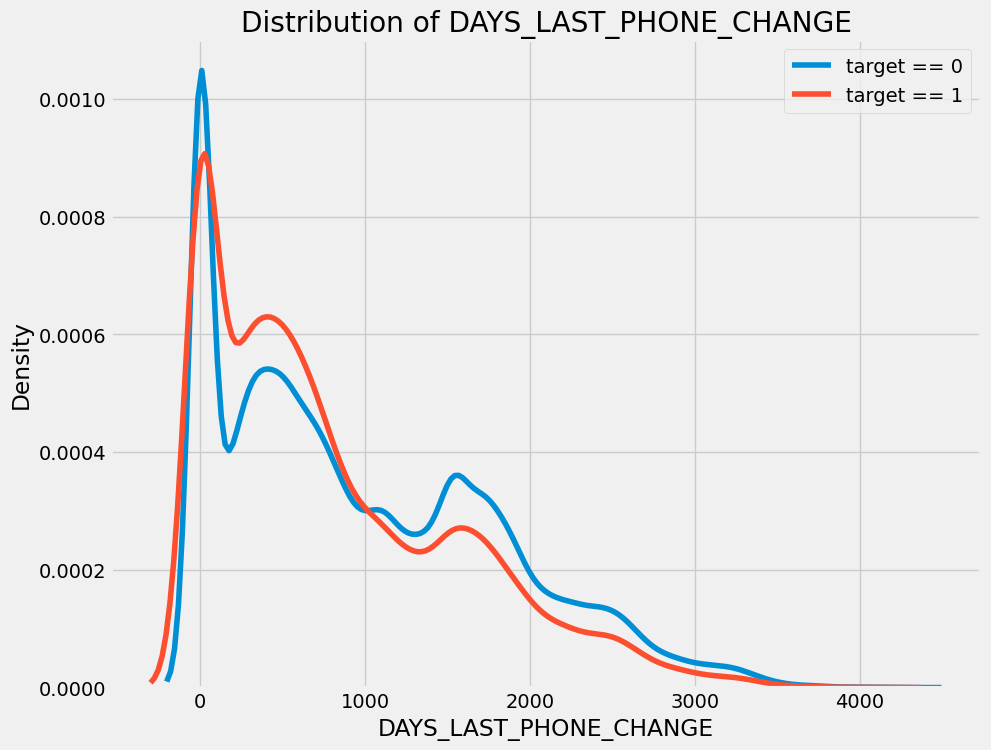

In [80]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 0, 'DAYS_LAST_PHONE_CHANGE'], label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(train.loc[train['TARGET'] == 1, 'DAYS_LAST_PHONE_CHANGE'], label = 'target == 1')

# Labeling of plot
plt.xlabel('DAYS_LAST_PHONE_CHANGE'); plt.ylabel('Density'); plt.title('Distribution of DAYS_LAST_PHONE_CHANGE')

plt.legend()

In [81]:
phone_change = train[['TARGET', 'DAYS_LAST_PHONE_CHANGE']]
phone_change

,TARGET,DAYS_LAST_PHONE_CHANGE
0,1,1134.0
1,0,828.0
2,0,815.0
3,0,617.0
4,0,1106.0
...,...,...
307506,0,273.0
307507,0,0.0
307508,0,1909.0
307509,1,322.0


In [82]:
# Bin the age data
phone_change['PHONE_CHANGE_BIN'] = pd.cut(phone_change['DAYS_LAST_PHONE_CHANGE'], bins = np.linspace(0, 4300, num = 100))
phone_change

,TARGET,DAYS_LAST_PHONE_CHANGE,PHONE_CHANGE_BIN
0,1,1134.0,"(1129.293, 1172.727]"
1,0,828.0,"(825.253, 868.687]"
2,0,815.0,"(781.818, 825.253]"
3,0,617.0,"(608.081, 651.515]"
4,0,1106.0,"(1085.859, 1129.293]"
...,...,...,...
307506,0,273.0,"(260.606, 304.04]"
307507,0,0.0,NaN
307508,0,1909.0,"(1867.677, 1911.111]"
307509,1,322.0,"(304.04, 347.475]"


In [83]:
phone_change = phone_change[phone_change['PHONE_CHANGE_BIN'].notna()]
phone_change

,TARGET,DAYS_LAST_PHONE_CHANGE,PHONE_CHANGE_BIN
0,1,1134.0,"(1129.293, 1172.727]"
1,0,828.0,"(825.253, 868.687]"
2,0,815.0,"(781.818, 825.253]"
3,0,617.0,"(608.081, 651.515]"
4,0,1106.0,"(1085.859, 1129.293]"
...,...,...,...
307503,0,2315.0,"(2302.02, 2345.455]"
307506,0,273.0,"(260.606, 304.04]"
307508,0,1909.0,"(1867.677, 1911.111]"
307509,1,322.0,"(304.04, 347.475]"


In [84]:
phone_change = phone_change.groupby(['PHONE_CHANGE_BIN']).mean()
phone_change = phone_change[phone_change['DAYS_LAST_PHONE_CHANGE'].notna()]
phone_change

,TARGET,DAYS_LAST_PHONE_CHANGE
PHONE_CHANGE_BIN,,
"(0.0, 43.434]",0.083854,8.747464
"(43.434, 86.869]",0.100427,64.467236
"(86.869, 130.303]",0.101992,109.960749
"(130.303, 173.737]",0.098742,153.015514
"(173.737, 217.172]",0.096414,195.403857
...,...,...
"(4039.394, 4082.828]",0.250000,4060.875000
"(4082.828, 4126.263]",0.000000,4113.400000
"(4126.263, 4169.697]",0.000000,4137.333333


Text(0.5, 1.0, 'Failure to Repay by DAYS_LAST_PHONE_CHANGE')

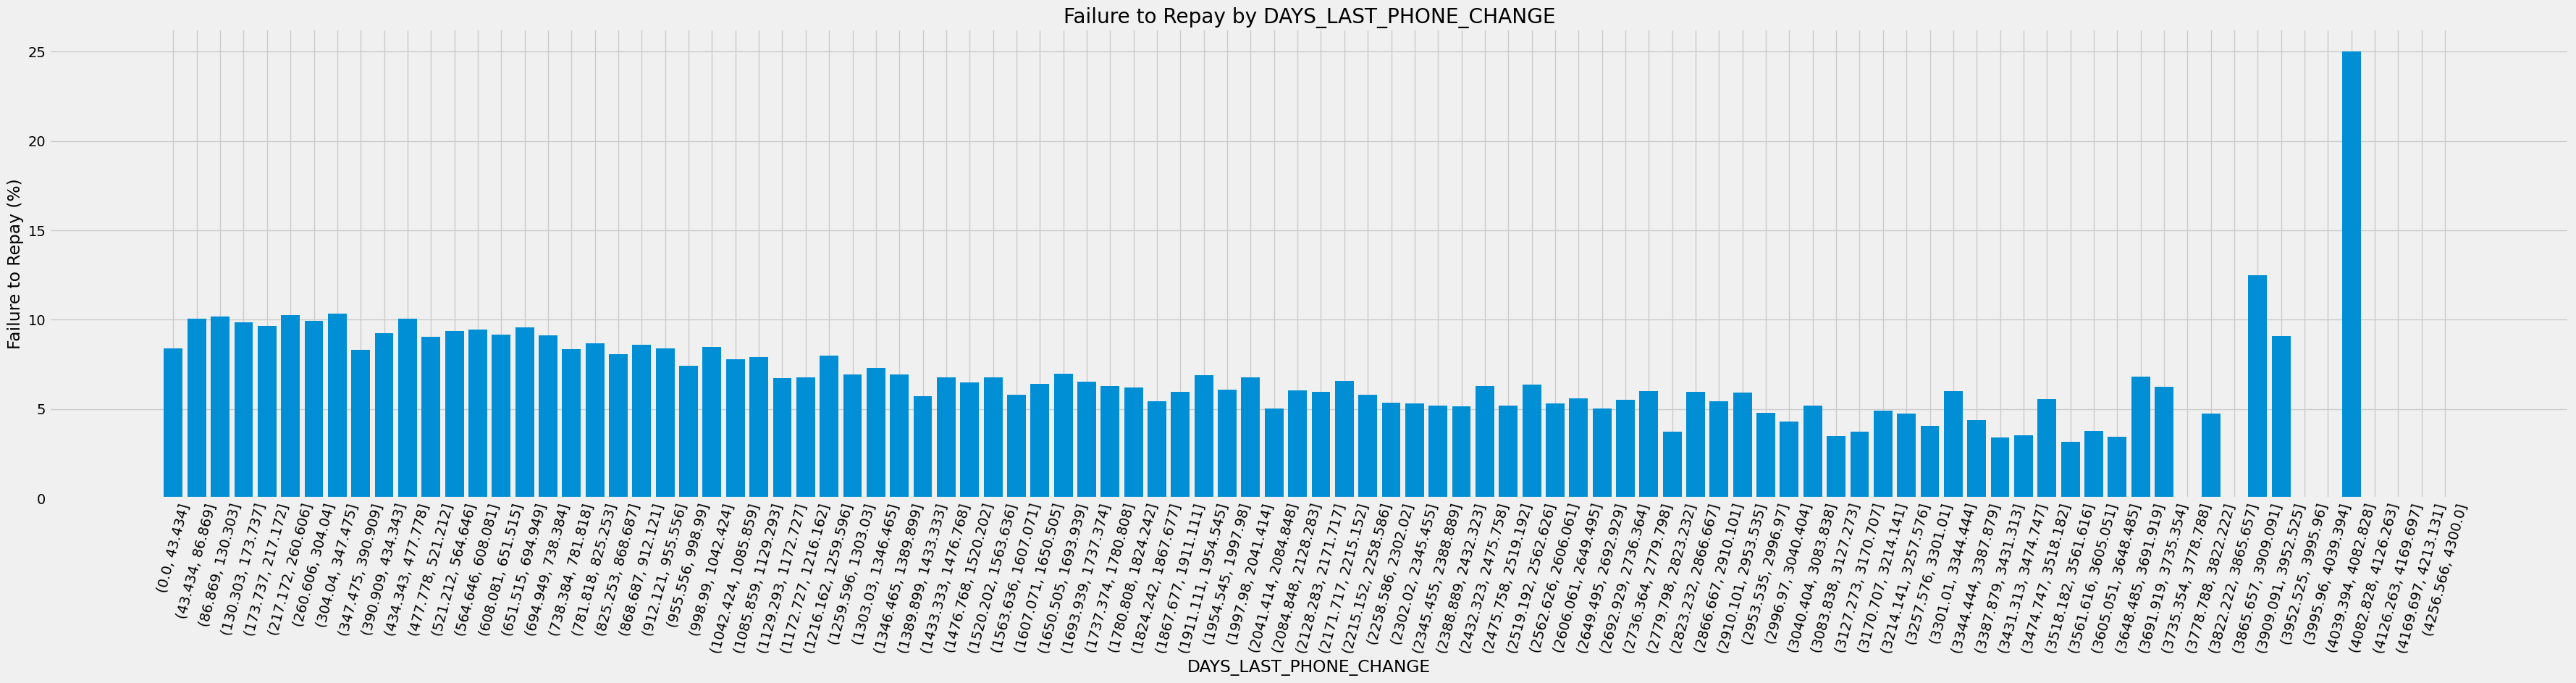

In [85]:
plt.figure(figsize = (40, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(phone_change.index.astype(str), 100 * phone_change['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('DAYS_LAST_PHONE_CHANGE'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by DAYS_LAST_PHONE_CHANGE')